This is data is coming from a public dataset provided by the city of Austin, Texas. It is important to remember that this analysis may be impacted by the fact that Austin, Texas identifies as a no kill city. 

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Current directory:", os.getcwd())

# Load the data
intakes = pd.read_csv('/Users/victorialarrazolo/Documents/animal_shelter_project/data/Austin_Animal_Center_Intakes_(10_01_2013_to_05_05_2025)_20260811.csv')
outcomes = pd.read_csv('/Users/victorialarrazolo/Documents/animal_shelter_project/data/Austin_Animal_Center_Outcomes_(10_01_2013_to_05_05_2025)_20260811.csv')

print("INTAKES")
print(f"Rows: {len(intakes):,}")
print(f"Columns: {intakes.columns.tolist()}")
print()
print("OUTCOMES")
print(f"Rows: {len(outcomes):,}")
print(f"Columns: {outcomes.columns.tolist()}")

Current directory: /Users/victorialarrazolo/Documents/animal_shelter_project/notebooks
INTAKES
Rows: 173,812
Columns: ['Animal ID', 'Name', 'DateTime', 'MonthYear', 'Found Location', 'Intake Type', 'Intake Condition', 'Animal Type', 'Sex upon Intake', 'Age upon Intake', 'Breed', 'Color']

OUTCOMES
Rows: 173,775
Columns: ['Animal ID', 'Date of Birth', 'Name', 'DateTime', 'MonthYear', 'Outcome Type', 'Outcome Subtype', 'Animal Type', 'Sex upon Outcome', 'Age upon Outcome', 'Breed', 'Color']


In [94]:
# Look at the unique values in the most important columns

print("INTAKE TYPES")
print(intakes['Intake Type'].value_counts())
print()

print("SEX UPON INTAKE (spay/neuter status)")
print(intakes['Sex upon Intake'].value_counts())
print()

print("ANIMAL TYPES")
print(intakes['Animal Type'].value_counts())
print()

print("OUTCOME TYPES")
print(outcomes['Outcome Type'].value_counts())
print()

print("MISSING VALUES - INTAKES")
print(intakes.isnull().sum())
print()

print("MISSING VALUES - OUTCOMES")
print(outcomes.isnull().sum())

INTAKE TYPES
Intake Type
Stray                 119160
Owner Surrender        35563
Public Assist          10432
Wildlife                6483
Abandoned               1910
Euthanasia Request       264
Name: count, dtype: int64

SEX UPON INTAKE (spay/neuter status)
Sex upon Intake
Intact Male      58996
Intact Female    56714
Neutered Male    24236
Spayed Female    20324
Unknown          13541
Name: count, dtype: int64

ANIMAL TYPES
Animal Type
Dog          94608
Cat          69324
Other         8968
Bird           878
Livestock       34
Name: count, dtype: int64

OUTCOME TYPES
Outcome Type
Adoption           84598
Transfer           48689
Return to Owner    25691
Euthanasia         10833
Died                1672
Rto-Adopt           1241
Disposal             877
Missing               92
Relocate              29
Stolen                 5
Lost                   2
Name: count, dtype: int64

MISSING VALUES - INTAKES
Animal ID               0
Name                49991
DateTime                0


In [95]:

# DATA CLEANING


# 1. Make copies of originals 
intakes_clean = intakes.copy()
outcomes_clean = outcomes.copy()

# 2. Parse DateTime columns
intakes_clean['DateTime'] = pd.to_datetime(intakes_clean['DateTime'])
outcomes_clean['DateTime'] = pd.to_datetime(outcomes_clean['DateTime'], format='mixed')
# 3. Extract useful date parts
intakes_clean['intake_year'] = intakes_clean['DateTime'].dt.year
intakes_clean['intake_month'] = intakes_clean['DateTime'].dt.month
intakes_clean['intake_month_name'] = intakes_clean['DateTime'].dt.strftime('%B')

# 4. Create a clean spay/neuter status column
def sterilization_status(sex):
    if pd.isna(sex):
        return 'Unknown'
    sex = str(sex).strip()
    if sex in ['Spayed Female', 'Neutered Male']:
        return 'Sterilized'
    elif sex in ['Intact Female', 'Intact Male']:
        return 'Intact'
    else:
        return 'Unknown'

intakes_clean['sterilized'] = intakes_clean['Sex upon Intake'].apply(sterilization_status)

# 5. Create a clean sex column (separate from sterilization)
def clean_sex(sex):
    if pd.isna(sex):
        return 'Unknown'
    sex = str(sex).strip()
    if 'Female' in sex:
        return 'Female'
    elif 'Male' in sex:
        return 'Male'
    else:
        return 'Unknown'

intakes_clean['sex'] = intakes_clean['Sex upon Intake'].apply(clean_sex)

# 6. Filter to just dogs and cats (main focus)
intakes_dc = intakes_clean[intakes_clean['Animal Type'].isin(['Dog', 'Cat'])].copy()
outcomes_dc = outcomes_clean[outcomes_clean['Animal Type'].isin(['Dog', 'Cat'])].copy()

# 7. Create outcome categories (simplified)
def outcome_category(outcome):
    if pd.isna(outcome):
        return 'Unknown'
    if outcome in ['Adoption', 'Rto-Adopt']:
        return 'Adopted'
    elif outcome == 'Return to Owner':
        return 'Returned to Owner'
    elif outcome == 'Transfer':
        return 'Transferred'
    elif outcome == 'Euthanasia':
        return 'Euthanized'
    else:
        return 'Other'

outcomes_dc['outcome_category'] = outcomes_dc['Outcome Type'].apply(outcome_category)

# 8. Merge intakes and outcomes on Animal ID
merged = intakes_dc.merge(
    outcomes_dc[['Animal ID', 'DateTime', 'outcome_category', 'Outcome Type', 'Outcome Subtype', 'Sex upon Outcome']],
    on='Animal ID',
    how='left',
    suffixes=('_intake', '_outcome')
)

## 9. Calculate length of stay in days
merged['DateTime_intake'] = pd.to_datetime(merged['DateTime_intake'], utc=True)
merged['DateTime_outcome'] = pd.to_datetime(merged['DateTime_outcome'], utc=True)
merged['length_of_stay'] = (merged['DateTime_outcome'] - merged['DateTime_intake']).dt.days
# 10. Quick summary
print("CLEAN AND MERGED DATASET")
print(f"Total dogs and cats: {len(merged):,}")
print()
print("Sterilization status breakdown:")
print(merged['sterilized'].value_counts())
print()
print("Outcome category breakdown:")
print(merged['outcome_category'].value_counts())
print()
print("Average length of stay (days):", round(merged['length_of_stay'].mean(), 1))

/var/folders/dh/30j8bpbx0lz1bmngkqg_s7rr0000gn/T/ipykernel_20017/3688356938.py:10: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  outcomes_clean['DateTime'] = pd.to_datetime(outcomes_clean['DateTime'], format='mixed')


CLEAN AND MERGED DATASET
Total dogs and cats: 212,142

Sterilization status breakdown:
sterilized
Intact        129735
Sterilized     76596
Unknown         5811
Name: count, dtype: int64

Outcome category breakdown:
outcome_category
Adopted              109826
Transferred           51519
Returned to Owner     42800
Euthanized             5228
Other                  1861
Unknown                  61
Name: count, dtype: int64

Average length of stay (days): 21.0


In [96]:
print("CLEANED AND MERGED DATASET")
print(f"Total dogs and cats: {len(merged):,}")
print()
print("Sterilization status breakdown:")
print(merged['sterilized'].value_counts())
print()
print("Outcome category breakdown:")
print(merged['outcome_category'].value_counts())
print()
print(f"Average length of stay (days): {round(merged['length_of_stay'].mean(), 1)}")
print()
print("Sample of merged data:")
print(merged[['Animal ID', 'Animal Type', 'Intake Type', 'sterilized', 'outcome_category', 'length_of_stay']].head(10))

CLEANED AND MERGED DATASET
Total dogs and cats: 212,142

Sterilization status breakdown:
sterilized
Intact        129735
Sterilized     76596
Unknown         5811
Name: count, dtype: int64

Outcome category breakdown:
outcome_category
Adopted              109826
Transferred           51519
Returned to Owner     42800
Euthanized             5228
Other                  1861
Unknown                  61
Name: count, dtype: int64

Average length of stay (days): 21.0

Sample of merged data:
  Animal ID Animal Type      Intake Type  sterilized   outcome_category  \
0   A521520         Dog            Stray  Sterilized  Returned to Owner   
1   A664235         Cat            Stray     Unknown        Transferred   
2   A664236         Cat            Stray     Unknown        Transferred   
3   A664237         Cat            Stray     Unknown        Transferred   
4   A664233         Dog            Stray      Intact         Euthanized   
5   A664238         Cat            Stray     Unknown        

In [97]:

# STERILIZATION TRENDS VS STRAY INTAKE OVER TIME

# Filter to dogs and cats only, exclude unknown sterilization
dc = merged[merged['Animal Type'].isin(['Dog', 'Cat'])].copy()

# 1. Stray intake volume by year
stray_by_year = dc[dc['Intake Type'] == 'Stray'].groupby('intake_year').size().reset_index()
stray_by_year.columns = ['year', 'stray_intake']

# 2. Sterilization rate at intake by year
steril_by_year = dc[dc['sterilized'].isin(['Intact', 'Sterilized'])].groupby(
    ['intake_year', 'sterilized']
).size().unstack(fill_value=0).reset_index()
steril_by_year.columns = ['year', 'Intact', 'Sterilized']
steril_by_year['total'] = steril_by_year['Intact'] + steril_by_year['Sterilized']
steril_by_year['sterilization_rate'] = (
    steril_by_year['Sterilized'] / steril_by_year['total'] * 100
).round(1)

# 3. Combine
trend = stray_by_year.merge(steril_by_year[['year', 'Sterilized', 'sterilization_rate']], on='year')
trend.columns = ['year', 'stray_intake', 'sterilized_count', 'sterilization_rate_pct']

print("STRAY INTAKE AND STERILIZATION RATE OVER TIME")
print(trend.to_string(index=False))
print()

# 4. Correlation
correlation = trend['stray_intake'].corr(trend['sterilization_rate_pct'])
print(f"Correlation between sterilization rate and stray intake: {correlation:.3f}")
print()
print("(A negative number means as sterilization rate goes up, stray intake goes down)")

# 5. Split by species
print()
print("BY SPECIES ")
for species in ['Dog', 'Cat']:
    subset = dc[dc['Animal Type'] == species]
    
    stray_s = subset[subset['Intake Type'] == 'Stray'].groupby('intake_year').size().reset_index()
    stray_s.columns = ['year', 'stray_intake']
    
    steril_s = subset[subset['sterilized'].isin(['Intact', 'Sterilized'])].groupby(
        ['intake_year', 'sterilized']
    ).size().unstack(fill_value=0).reset_index()
    steril_s.columns = ['year', 'Intact', 'Sterilized']
    steril_s['sterilization_rate'] = (
        steril_s['Sterilized'] / 
        (steril_s['Intact'] + steril_s['Sterilized']) * 100
    ).round(1)
    
    trend_s = stray_s.merge(steril_s[['year', 'sterilization_rate']], on='year')
    corr_s = trend_s['stray_intake'].corr(trend_s['sterilization_rate'])
    print(f"{species}: correlation = {corr_s:.3f}")

STRAY INTAKE AND STERILIZATION RATE OVER TIME
 year  stray_intake  sterilized_count  sterilization_rate_pct
 2013          3373              1677                    36.0
 2014         15548              7847                    36.8
 2015         16862              9257                    41.8
 2016         15738              9436                    43.1
 2017         15303              9745                    43.6
 2018         15331              9557                    43.1
 2019         16906              9286                    38.3
 2020          6829              4063                    36.3
 2021          8590              4651                    32.3
 2022          8471              3757                    28.0
 2023          8354              3065                    25.1
 2024          8855              3195                    25.3
 2025          2565              1060                    28.5

Correlation between sterilization rate and stray intake: 0.689

(A negative number me

In [98]:

# ERA ANALYSIS: PRE vs POST COVID


pre_covid = trend[trend['year'].between(2014, 2019)].copy()
post_covid = trend[trend['year'].between(2021, 2024)].copy()

print("PRE COVID (2014-2019)")
print(pre_covid[['year', 'stray_intake', 'sterilization_rate_pct']].to_string(index=False))
corr_pre = pre_covid['stray_intake'].corr(pre_covid['sterilization_rate_pct'])
print(f"Correlation: {corr_pre:.3f}")
print()

print("POST-COVID (2021-2024)")
print(post_covid[['year', 'stray_intake', 'sterilization_rate_pct']].to_string(index=False))
corr_post = post_covid['stray_intake'].corr(post_covid['sterilization_rate_pct'])
print(f"Correlation: {corr_post:.3f}")
print()

# Also look at pre-covid sterilization trend vs stray trend
print("PRE-COVID YEAR OVER YEAR CHANGES")
pre_covid = pre_covid.copy()
pre_covid['stray_change_pct'] = pre_covid['stray_intake'].pct_change() * 100
pre_covid['steril_rate_change'] = pre_covid['sterilization_rate_pct'].diff()
print(pre_covid[['year', 'stray_intake', 'stray_change_pct', 
                  'sterilization_rate_pct', 'steril_rate_change']].round(1).to_string(index=False))


PRE COVID (2014-2019)
 year  stray_intake  sterilization_rate_pct
 2014         15548                    36.8
 2015         16862                    41.8
 2016         15738                    43.1
 2017         15303                    43.6
 2018         15331                    43.1
 2019         16906                    38.3
Correlation: -0.337

POST-COVID (2021-2024)
 year  stray_intake  sterilization_rate_pct
 2021          8590                    32.3
 2022          8471                    28.0
 2023          8354                    25.1
 2024          8855                    25.3
Correlation: -0.028

PRE-COVID YEAR OVER YEAR CHANGES
 year  stray_intake  stray_change_pct  sterilization_rate_pct  steril_rate_change
 2014         15548               NaN                    36.8                 NaN
 2015         16862               8.5                    41.8                 5.0
 2016         15738              -6.7                    43.1                 1.3
 2017         15303     

In [99]:
# LAG EFFECT: Does sterilization rate in 
# year X predict stray intake in year X+1?

# Create a version of trend with sterilization rate shifted by 1 year
trend_lag = trend.copy()
trend_lag['sterilization_rate_lag1'] = trend_lag['sterilization_rate_pct'].shift(1)
trend_lag['sterilization_rate_lag2'] = trend_lag['sterilization_rate_pct'].shift(2)

# Drop rows where we don't have lag data
trend_lag = trend_lag.dropna()

# Pre-COVID only for clean analysis
pre_covid_lag = trend_lag[trend_lag['year'].between(2015, 2019)]

print(" LAG EFFECT ANALYSIS (Pre-COVID)")
print()
corr_same = pre_covid_lag['stray_intake'].corr(pre_covid_lag['sterilization_rate_pct'])
corr_lag1 = pre_covid_lag['stray_intake'].corr(pre_covid_lag['sterilization_rate_lag1'])
corr_lag2 = pre_covid_lag['stray_intake'].corr(pre_covid_lag['sterilization_rate_lag2'])

print(f"Correlation with same year sterilization rate:     {corr_same:.3f}")
print(f"Correlation with prior year sterilization rate:    {corr_lag1:.3f}")
print(f"Correlation with 2-year prior sterilization rate:  {corr_lag2:.3f}")
print()
print("(More negative = stronger effect. A 1-year lag would suggest")
print("sterilizations take about a year to reduce stray populations)")

 LAG EFFECT ANALYSIS (Pre-COVID)

Correlation with same year sterilization rate:     -0.818
Correlation with prior year sterilization rate:    -0.581
Correlation with 2-year prior sterilization rate:  -0.236

(More negative = stronger effect. A 1-year lag would suggest
sterilizations take about a year to reduce stray populations)


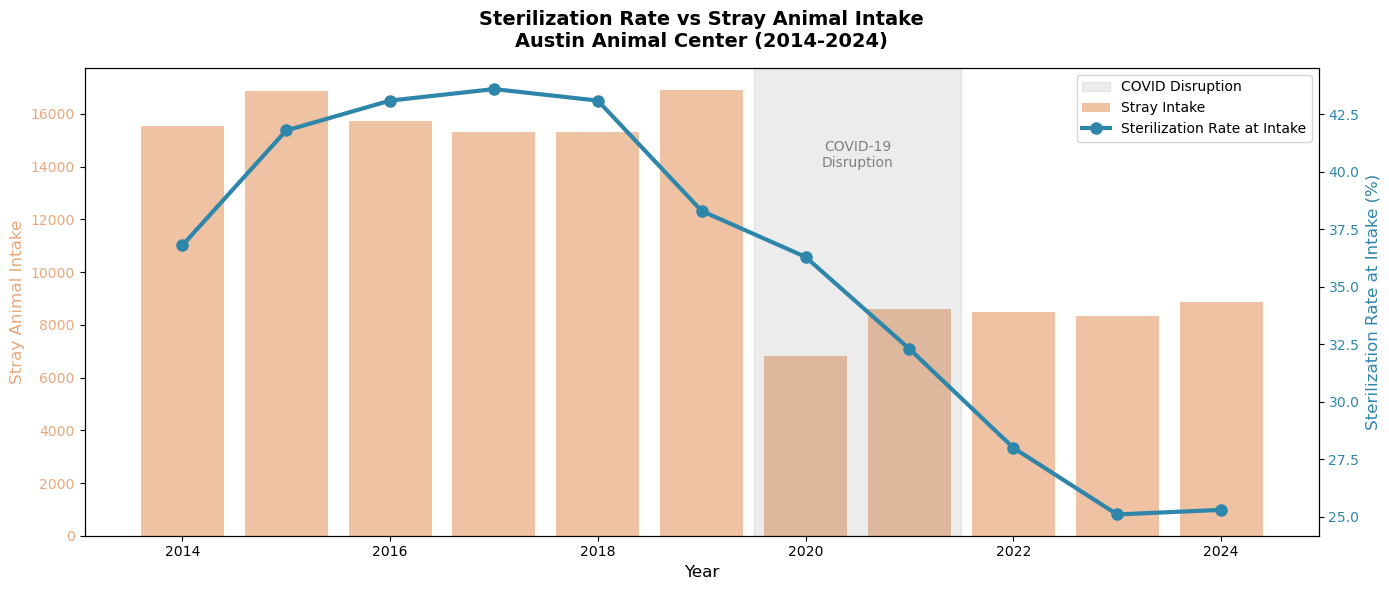

Chart 1 saved.


In [100]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Set style
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'sans-serif'
sns.set_palette('husl')

# CHART 1: Sterilization Rate vs Stray Intake
# Over Time (the headline finding)


fig, ax1 = plt.subplots(figsize=(14, 6))

# Filter out partial years
trend_plot = trend[(trend['year'] >= 2014) & (trend['year'] <= 2024)]

# Stray intake bars
bars = ax1.bar(trend_plot['year'], trend_plot['stray_intake'], 
               color='#E8A87C', alpha=0.7, label='Stray Intake')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Stray Animal Intake', fontsize=12, color='#E8A87C')
ax1.tick_params(axis='y', labelcolor='#E8A87C')

# Sterilization rate line on second axis
ax2 = ax1.twinx()
ax2.plot(trend_plot['year'], trend_plot['sterilization_rate_pct'], 
         color='#2E86AB', linewidth=3, marker='o', markersize=8,
         label='Sterilization Rate at Intake')
ax2.set_ylabel('Sterilization Rate at Intake (%)', fontsize=12, color='#2E86AB')
ax2.tick_params(axis='y', labelcolor='#2E86AB')

# COVID annotation
ax1.axvspan(2019.5, 2021.5, alpha=0.15, color='gray', label='COVID Disruption')
ax1.annotate('COVID-19\nDisruption', xy=(2020.5, 14000), fontsize=10, 
             ha='center', color='gray')

plt.title('Sterilization Rate vs Stray Animal Intake\nAustin Animal Center (2014-2024)', 
          fontsize=14, fontweight='bold', pad=15)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig('../tableau/chart1_sterilization_vs_stray.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved.")

In [101]:
#CLEAN FOR TABLEAU EXPORT


print("Export 1 (trend_summary) already done.")
print(trend[['year','stray_intake','sterilization_rate_pct']].to_string(index=False))
print()

# EXPORT 2: Outcomes by sterilization (with percentages) 
outcome_pct = analysis.groupby(
    ['Animal Type', 'sterilized', 'outcome_category']
).size().reset_index(name='count')

# Add percentage within each Animal Type + sterilized group
outcome_pct['total'] = outcome_pct.groupby(
    ['Animal Type', 'sterilized']
)['count'].transform('sum')
outcome_pct['percentage'] = (outcome_pct['count'] / outcome_pct['total'] * 100).round(1)

outcome_pct.to_csv('../tableau/outcomes_by_sterilization.csv', index=False)
print("Export 2 (outcomes_by_sterilization) saved.")
print(outcome_pct[outcome_pct['Animal Type']=='Dog'].to_string(index=False))
print()

# EXPORT 3: Seasonal patterns (monthly averages pre-COVID) 
seasonal_avg = merged[
    (merged['Animal Type'].isin(['Dog', 'Cat'])) &
    (merged['Intake Type'] == 'Stray') &
    (merged['intake_year'].between(2014, 2019))
].groupby(['intake_month', 'intake_month_name', 'Animal Type']).size().reset_index(name='total_count')

# Average per year (6 years of pre-COVID data)
seasonal_avg['avg_monthly_intake'] = (seasonal_avg['total_count'] / 6).round(0)
seasonal_avg = seasonal_avg.sort_values(['Animal Type', 'intake_month'])
seasonal_avg.to_csv('../tableau/seasonal_avg.csv', index=False)
print("Export 3 (seasonal_avg) saved.")
print(seasonal_avg[seasonal_avg['Animal Type']=='Cat'].to_string(index=False))
print()

# EXPORT 4: Decade of progress (live outcome rate by year) 
yearly_outcomes = merged[
    merged['Animal Type'].isin(['Dog', 'Cat'])
].groupby(['intake_year', 'Animal Type', 'outcome_category']).size().reset_index(name='count')

yearly_total = merged[
    merged['Animal Type'].isin(['Dog', 'Cat'])
].groupby(['intake_year', 'Animal Type']).size().reset_index(name='total')

yearly_outcomes = yearly_outcomes.merge(yearly_total, on=['intake_year', 'Animal Type'])
yearly_outcomes['percentage'] = (yearly_outcomes['count'] / yearly_outcomes['total'] * 100).round(1)

# Add a live outcome flag
live_outcomes = ['Adopted', 'Returned to Owner', 'Transferred']
yearly_outcomes['is_live'] = yearly_outcomes['outcome_category'].isin(live_outcomes)

live_rate = yearly_outcomes[yearly_outcomes['is_live']].groupby(
    ['intake_year', 'Animal Type']
)['percentage'].sum().reset_index()
live_rate.columns = ['year', 'Animal Type', 'live_outcome_rate_pct']

# Also add euthanasia rate
euth_rate_yearly = yearly_outcomes[
    yearly_outcomes['outcome_category'] == 'Euthanized'
][['intake_year', 'Animal Type', 'percentage']].copy()
euth_rate_yearly.columns = ['year', 'Animal Type', 'euthanasia_rate_pct']

decade = live_rate.merge(euth_rate_yearly, on=['year', 'Animal Type'], how='left')
decade['euthanasia_rate_pct'] = decade['euthanasia_rate_pct'].fillna(0).round(1)
decade = decade[decade['year'].between(2014, 2024)]

decade.to_csv('../tableau/decade_progress.csv', index=False)
print("Export 4 (decade_progress) saved.")
print(decade.to_string(index=False))

# EXPORT 5: Euthanasia rate by species and sterilization 
euth_steril = []
for species in ['Dog', 'Cat']:
    for status in ['Intact', 'Sterilized']:
        subset = analysis[
            (analysis['Animal Type'] == species) &
            (analysis['sterilized'] == status)
        ]
        total = len(subset)
        euthanized = (subset['outcome_category'] == 'Euthanized').sum()
        euth_steril.append({
            'species': species,
            'sterilization_status': status,
            'total_animals': total,
            'euthanized_count': euthanized,
            'euthanasia_rate_pct': round(euthanized / total * 100, 2)
        })

euth_df_export = pd.DataFrame(euth_steril)
euth_df_export.to_csv('../tableau/euthanasia_by_species_sterilization.csv', index=False)
print()
print("Export 5 (euthanasia_by_species_sterilization) saved.")
print(euth_df_export.to_string(index=False))

Export 1 (trend_summary) already done.
 year  stray_intake  sterilization_rate_pct
 2013          3373                    36.0
 2014         15548                    36.8
 2015         16862                    41.8
 2016         15738                    43.1
 2017         15303                    43.6
 2018         15331                    43.1
 2019         16906                    38.3
 2020          6829                    36.3
 2021          8590                    32.3
 2022          8471                    28.0
 2023          8354                    25.1
 2024          8855                    25.3
 2025          2565                    28.5

Export 2 (outcomes_by_sterilization) saved.
Animal Type sterilized  outcome_category  count  total  percentage
        Dog     Intact           Adopted  41040  75740        54.2
        Dog     Intact        Euthanized   1600  75740         2.1
        Dog     Intact             Other    429  75740         0.6
        Dog     Intact Returned 